In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
fs =1000
t = np.arange(0, 1, 1/fs)

#useful signal
signal_clean = (
    np.sin(2*np.pi*20*t) +
    0.5*np.sin(2*np.pi*40*t)
)

# 60 Hz interference
line_noise = 0.7 * np.sin(2*np.pi*60*t)

# random noise
np.random.seed(42)
noise = 0.2 * np.random.randn(len(t))

#combined_signal

x = signal_clean + line_noise + noise


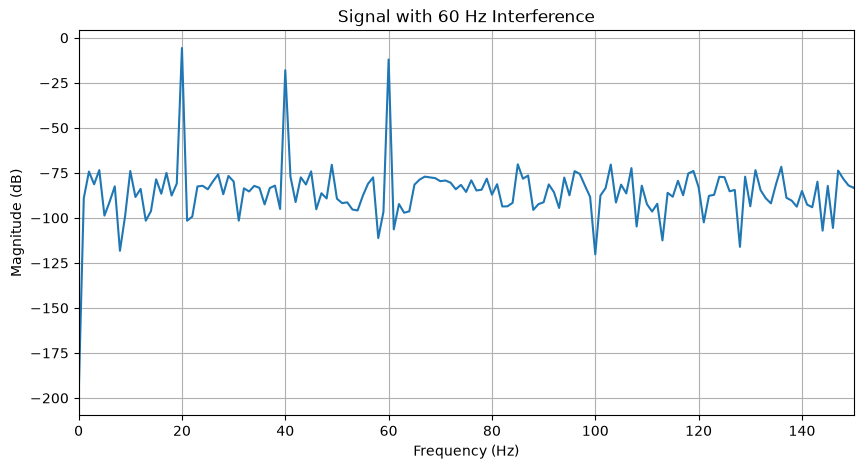

In [3]:
f , X = signal.periodogram(x, fs=fs)
plt.figure(figsize=(10, 5))
plt.plot(f, 20*np.log10(np.maximum(np.abs(X), 1e-10)))

plt.xlim(0, 150)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Signal with 60 Hz Interference")
plt.grid()
plt.show()


In [5]:
# notch filter
f0 = 60
Q = 30

b_notch, a_notch = signal.iirnotch(
    w0=f0,
    Q=Q,
    fs=fs
)

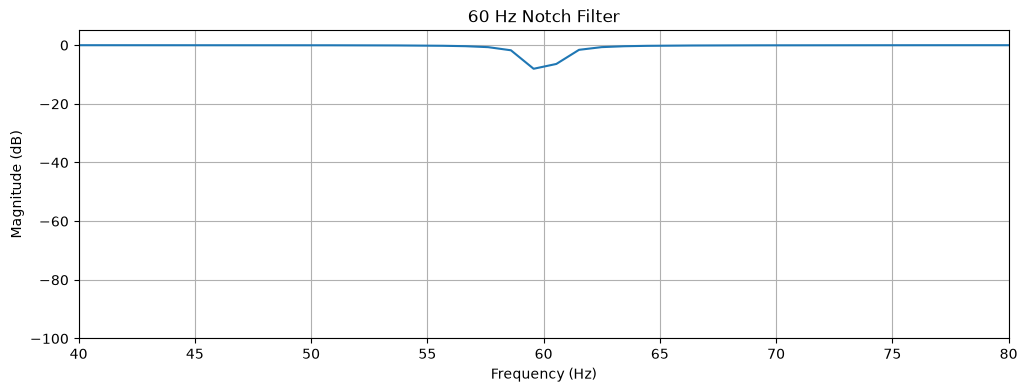

In [8]:
f_notch, h_notch = signal.freqz(b_notch, a_notch, fs=fs)

plt.figure(figsize = (12, 4))
plt.plot(f_notch, 20*np.log10(np.maximum(np.abs(h_notch), 1e-10)))
plt.xlim(40, 80)
plt.ylim(-100, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("60 Hz Notch Filter")
plt.grid()
plt.show()

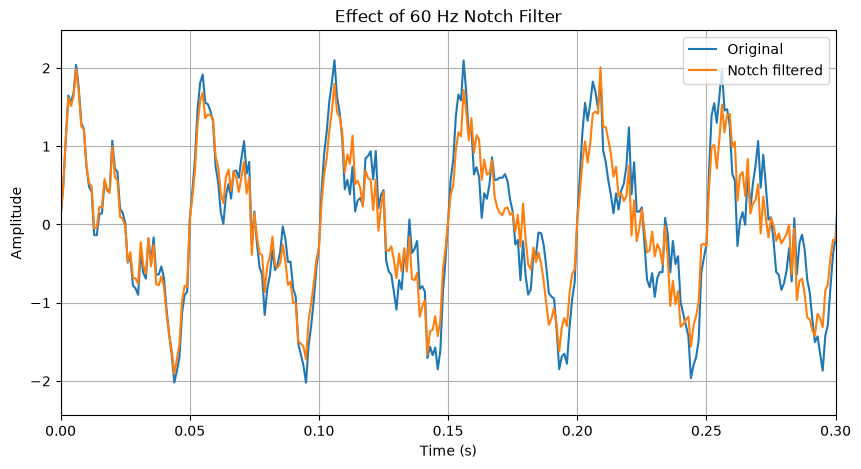

In [10]:
y_notch = signal.lfilter(b_notch, a_notch, x)
plt.figure(figsize=(10, 5))

plt.plot(t, x, label="Original")
plt.plot(t, y_notch, label="Notch filtered")

plt.xlim(0, 0.3)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Effect of 60 Hz Notch Filter")
plt.legend()
plt.grid()
plt.show()


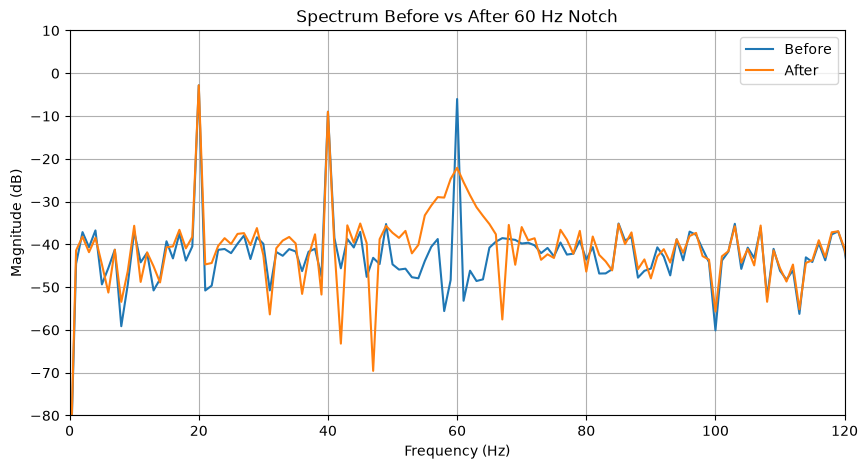

In [13]:
f_before, X_before = signal.periodogram(x, fs=fs)
f_after, X_after = signal.periodogram(y_notch, fs=fs)

plt.figure(figsize=(10, 5))

plt.plot(
    f_before,
    10*np.log10(np.maximum(np.abs(X_before), 1e-10)),
    label="Before"
)

plt.plot(
    f_after,
    10*np.log10(np.maximum(np.abs(X_after), 1e-10)),
    label="After"
)

plt.xlim(0, 120)
plt.ylim(-80, 10)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Spectrum Before vs After 60 Hz Notch")
plt.legend()
plt.grid()
plt.show()

In [14]:
idx_60_before = np.argmin(np.abs(f_before - 60))
idx_60_after = np.argmin(np.abs(f_after - 60))

mag_60_before = np.abs(X_before[idx_60_before])
mag_60_after = np.abs(X_after[idx_60_after])

attenuation_60 = 10 * np.log10(
    mag_60_after / mag_60_before
)

print("60 Hz magnitude before:", mag_60_before)
print("60 Hz magnitude after:", mag_60_after)
print("60 Hz attenuation:", attenuation_60, "dB")

60 Hz magnitude before: 0.2502574213576366
60 Hz magnitude after: 0.006173167676453258
60 Hz attenuation: -16.07878891804284 dB


In [15]:
idx20 = np.argmin(np.abs(f_before - 20))
idx40 = np.argmin(np.abs(f_before - 40))
idx60 = np.argmin(np.abs(f_before - 60))

atten20_db = 10 * np.log10(X_after[idx20] / X_before[idx20])
atten40_db = 10 * np.log10(X_after[idx40] / X_before[idx40])
atten60_db = 10 * np.log10(X_after[idx60] / X_before[idx60])

print("20 Hz attenuation:", atten20_db, "dB")
print("40 Hz attenuation:", atten40_db, "dB")
print("60 Hz attenuation:", atten60_db, "dB")

20 Hz attenuation: -0.0014173540492691899 dB
40 Hz attenuation: -0.012332084632579433 dB
60 Hz attenuation: -16.07878891804284 dB


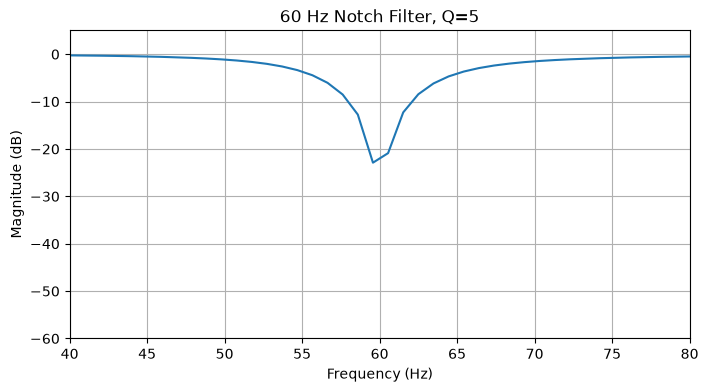

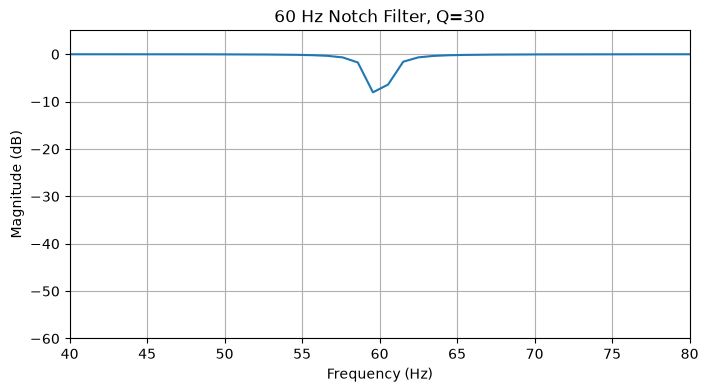

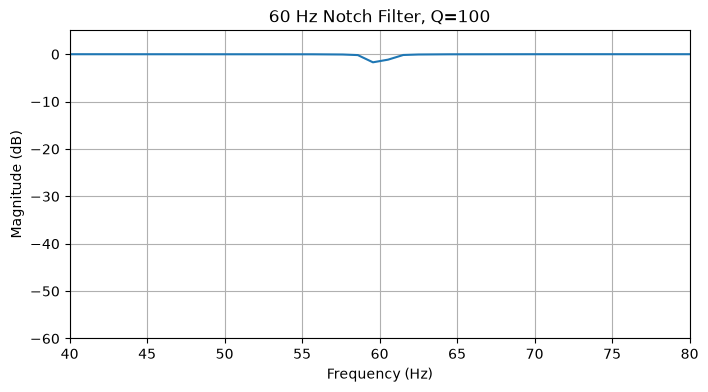

In [19]:
Q_values = [5, 30, 100]

for Q in Q_values:
    b_notch, a_notch = signal.iirnotch(w0=60, Q=Q, fs=fs)
    f, h = signal.freqz(b_notch, a_notch, fs=fs)

    magnitude_db = 20 * np.log10(np.maximum(np.abs(h), 1e-10))

    plt.figure(figsize=(8, 4))
    plt.plot(f, magnitude_db)
    plt.xlim(40, 80)
    plt.ylim(-60, 5)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"60 Hz Notch Filter, Q={Q}")
    plt.grid()
    plt.show()

In [20]:
fs = 1000
t = np.arange(0, 2, 1/fs)

signal_clean = np.sin(2*np.pi*20*t)

noise_59 = 0.7*np.sin(2*np.pi*59*t)
noise_60 = 0.7*np.sin(2*np.pi*60*t)
noise_61 = 0.7*np.sin(2*np.pi*61*t)

In [21]:
f0 = 60
Q = 30

b_notch, a_notch = signal.iirnotch(
    w0=f0,
    Q=Q,
    fs=fs
)

In [22]:
y_59 = signal.lfilter(b_notch, a_notch, signal_clean + noise_59)
y_60 = signal.lfilter(b_notch, a_notch, signal_clean + noise_60)
y_61 = signal.lfilter(b_notch, a_notch, signal_clean + noise_61)

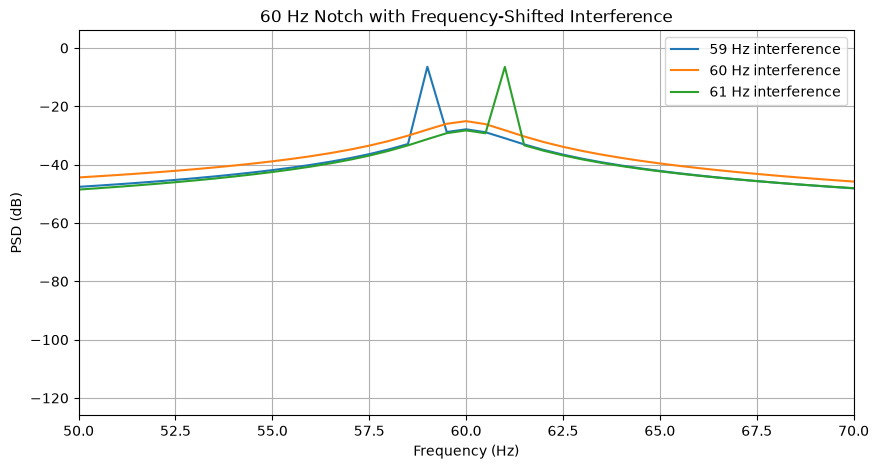

In [23]:
f59, X59 = signal.periodogram(y_59, fs=fs)
f60, X60 = signal.periodogram(y_60, fs=fs)
f61, X61 = signal.periodogram(y_61, fs=fs)

plt.figure(figsize=(10, 5))

plt.plot(f59, 10*np.log10(np.maximum(X59, 1e-12)), label="59 Hz interference")
plt.plot(f60, 10*np.log10(np.maximum(X60, 1e-12)), label="60 Hz interference")
plt.plot(f61, 10*np.log10(np.maximum(X61, 1e-12)), label="61 Hz interference")

plt.xlim(50, 70)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.title("60 Hz Notch with Frequency-Shifted Interference")
plt.legend()
plt.grid()
plt.show()